# PerovStats demo notebook
This notebook is for demonstrating the processes involved in PerovStats, from deciding on configuration options and running the modules.

In [1]:
%load_ext autoreload
%autoreload 2

import os
import sys
import time

from loguru import logger
from pathlib import Path
import yaml
from topostats.io import LoadScans
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

sys.path.append(os.path.abspath(os.path.join('..')))
from src.perovstats.core.classes import PerovStats, ImageData
from src.perovstats.core.io import save_to_csv, save_config
from src.perovstats.cli import setup_logger
from src.perovstats.fourier import split_frequencies
from src.perovstats.segmentation import segment_image_cellpose, normalise_array
from src.perovstats.pruning import prune_mask
from src.perovstats.smears import find_smear_areas
from src.perovstats.grains import find_grains

These options can be changed to suit your needs. the `output_dir` folder will contain a selection of images from various stages in the process as well as the `.csv` files generated.
In the full version of the notebook, `img_files` will be replaced with `img_dir` and will need to point to a directory containing .spm files rather than a single specific file.

In [2]:
img_files = [Path("../images/4_c60_perovonsil_ref_10um.PFQNM.spm")]
# img_files = [Path("../images/TR_5um_ST4_14_26_per_Si_tapp4.0_00010.spm")]
output_dir = Path("./output")
config_path = Path("../src/perovstats/default_config.yaml")

First, the `.spm` files are loaded and the original heightmap image is extracted.

[Tue, 31 Mar 2026 21:55:57] [INFO    ] [topostats] Extracting image from ..\images\4_c60_perovonsil_ref_10um.PFQNM.spm
21:55:57 | INFO    | spm.py          | Loading image from : ..\images\4_c60_perovonsil_ref_10um.PFQNM.spm
21:55:57 | INFO    | spm.py          | [4_c60_perovonsil_ref_10um.PFQNM] : Loaded image from : ..\images\4_c60_perovonsil_ref_10um.PFQNM.spm
21:55:57 | INFO    | spm.py          | [4_c60_perovonsil_ref_10um.PFQNM] : Extracted channel Height
21:55:57 | INFO    | spm.py          | [4_c60_perovonsil_ref_10um.PFQNM] : Pixel to nm scaling : 19.53125
21:55:57 | INFO    | 1114820156.py   | ----------------------------------------------------------
21:55:57 | INFO    | 1114820156.py   | Loaded 1 images


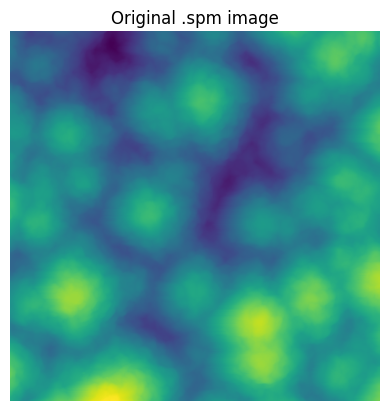

In [3]:
setup_logger()

with config_path.open() as f:
    config = yaml.safe_load(f)

time_start = time.perf_counter()

# Load scans
load_config = config["loading"]
loadscans = LoadScans(img_files, config)
try:
    loadscans.get_data()
except ValueError as e:
    logger.warning(e)
    logger.warning(f"Channel {load_config['channel']} not found in file. Please ensure the config option is correct and all files contain the required channel.")
image_dicts = loadscans.img_dict

# Create the dataclasses for the whole process and for each image found
perovstats_object = PerovStats(config=config, images=[])
for filename, topostats_object in image_dicts.items():
    image_data = ImageData(
        success=True,
        filename=filename,
        pixel_to_nm_scaling=topostats_object.pixel_to_nm_scaling,
        image_original=topostats_object.image_original,
        image_flattened=None)
    perovstats_object.images.append(image_data)

logger.info("----------------------------------------------------------")
logger.info(f"Loaded {len(perovstats_object.images)} images")

idx = 0
image_object = perovstats_object.images[0]

plt.imshow(image_object.image_original)
plt.title("Original .spm image")
plt.axis("off")
plt.show()

In [4]:
logger.info("----------------------------------------------------------")
logger.info(f"Processing {image_object.filename} ({idx+1}/{len(perovstats_object.images)})")
logger.info("----------------------------------------------------------")
logger.debug(f"[{image_object.filename}] : Image dimensions: {image_object.image_original.shape}")
logger.debug(f"[{image_object.filename}] : pixel_to_nm_scaling: {image_object.pixel_to_nm_scaling}")

21:55:57 | INFO    | 1697177067.py   | ----------------------------------------------------------
21:55:57 | INFO    | 1697177067.py   | Processing 4_c60_perovonsil_ref_10um.PFQNM.spm (1/1)
21:55:57 | INFO    | 1697177067.py   | ----------------------------------------------------------
21:55:57 | DEBUG   | 1697177067.py   | [4_c60_perovonsil_ref_10um.PFQNM.spm] : Image dimensions: (512, 512)
21:55:57 | DEBUG   | 1697177067.py   | [4_c60_perovonsil_ref_10um.PFQNM.spm] : pixel_to_nm_scaling: 19.53125


A fourier transform is then performed on the image which splits it into two sections, one containing the perovskite topology and one containing the silicon topology (to be discarded):

21:55:58 | INFO    | fourier.py      | [4_c60_perovonsil_ref_10um.PFQNM.spm] : *** Frequency splitting ***
21:55:58 | INFO    | fourier.py      | [4_c60_perovonsil_ref_10um.PFQNM.spm] : Frequency cutoff: 0.1295 (301.6591nm)
21:55:58 | INFO    | fourier.py      | [4_c60_perovonsil_ref_10um.PFQNM.spm] : Splitting image frequencies


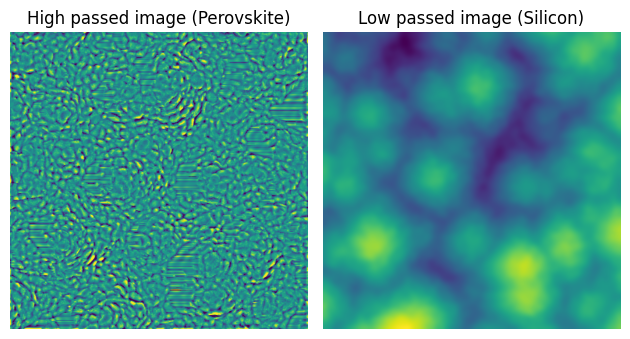

In [5]:
# Apply fourier transform to split the image into a low-passed and high-passed image
split_frequencies(perovstats_object.config, image_object)

# Show the split images
fig, ax = plt.subplots(1, 2)

ax[0].imshow(image_object.high_pass)
ax[0].set_title("High passed image (Perovskite)")
ax[0].axis("off")

ax[1].imshow(image_object.low_pass)
ax[1].set_title("Low passed image (Silicon)")
ax[1].axis("off")

plt.tight_layout()
plt.show()

The high passed image must now be segmented in order to find individual grain outlines. This uses a machine learning model and may take a few minutes depending on your device. For the quickest results, use a computer that has an Nvidia GPU:

21:55:59 | INFO    | segmentation.py | [4_c60_perovonsil_ref_10um.PFQNM.spm] : *** Mask creation ***
21:55:59 | INFO    | segmentation.py | [4_c60_perovonsil_ref_10um.PFQNM.spm] : Creating grain mask
21:55:59 | WARNING | segmentation.py | [4_c60_perovonsil_ref_10um.PFQNM.spm] : No Nvidia GPU detected, CPU is being used for segmentation. This may take a few minutes..


c:\Users\tobya\Documents\Work\PerovStats\.venv\Lib\site-packages\cellpose\dynamics.py:524: UserWarning: Sparse invariant checks are implicitly disabled. Memory errors (e.g. SEGFAULT) will occur when operating on a sparse tensor which violates the invariants, but checks incur performance overhead. To silence this warning, explicitly opt in or out. See `torch.sparse.check_sparse_tensor_invariants.__doc__` for guidance.  (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\Context.cpp:767.)
  coo = torch.sparse_coo_tensor(pt, torch.ones(pt.shape[1], device=pt.device, dtype=torch.int),
Resizing is deprecated in v4.0.1+


21:59:30 | INFO    | segmentation.py | [4_c60_perovonsil_ref_10um.PFQNM.spm] : Mask created, Returning image to original size.


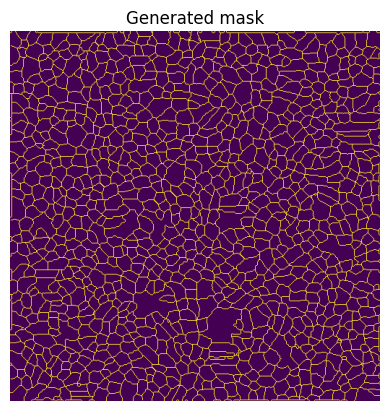

In [6]:
# Generate grain mask of the high-passed image
segment_image_cellpose(perovstats_object.config, image_object)

plt.imshow(image_object.mask)
plt.title("Generated mask")
plt.axis("off")
plt.show()

Sometimes small offshoots from the grain borders are created, we need to identify and remove these from the mask:

21:59:31 | INFO    | pruning.py      | [4_c60_perovonsil_ref_10um.PFQNM.spm] : *** Pruning ***


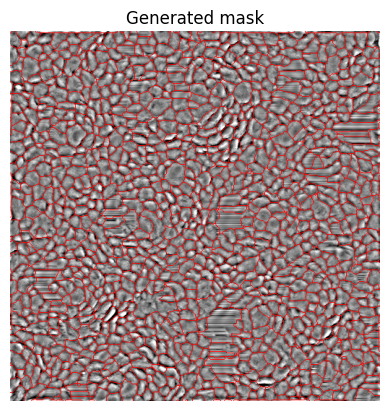

In [7]:
# Remove small offshoots in the mask and connect sections with small breaks
prune_mask(perovstats_object.config, image_object)

# Display the generated mask overlayed onto the high pass image
mask_overlay = np.stack((image_object.high_pass,)*3, axis=-1)
mask_overlay = normalise_array(mask_overlay)
mask_overlay[image_object.mask > 0] = [1, 0, 0]
plt.imshow(mask_overlay)
plt.title("Generated mask")
plt.axis("off")
plt.show()

Smear areas are errors in the AFM scan from the tip not being able to dip low enough after a peak, resulting in horizontal lines which should not be counted in the data. They are identified and grains within these areas are removed:

In [ ]:
# Find smear areas to be ignored/ removed
find_smear_areas(perovstats_object.config, image_object)

21:59:31 | INFO    | smears.py       | [4_c60_perovonsil_ref_10um.PFQNM.spm] : *** Finding smear areas ***
21:59:33 | INFO    | smears.py       | [4_c60_perovonsil_ref_10um.PFQNM.spm] : Smear areas found: 21 (11.7% of mask)


The mask (which is currently a collection of thin lines) should then be analysed in order to identify individual grains. Once this has been done stats can also be taken from these grains and displayed in graphs:

21:59:33 | INFO    | grains.py       | [4_c60_perovonsil_ref_10um.PFQNM.spm] : *** Grain finding ***
21:59:33 | INFO    | grains.py       | [4_c60_perovonsil_ref_10um.PFQNM.spm] : Obtained 701 grains


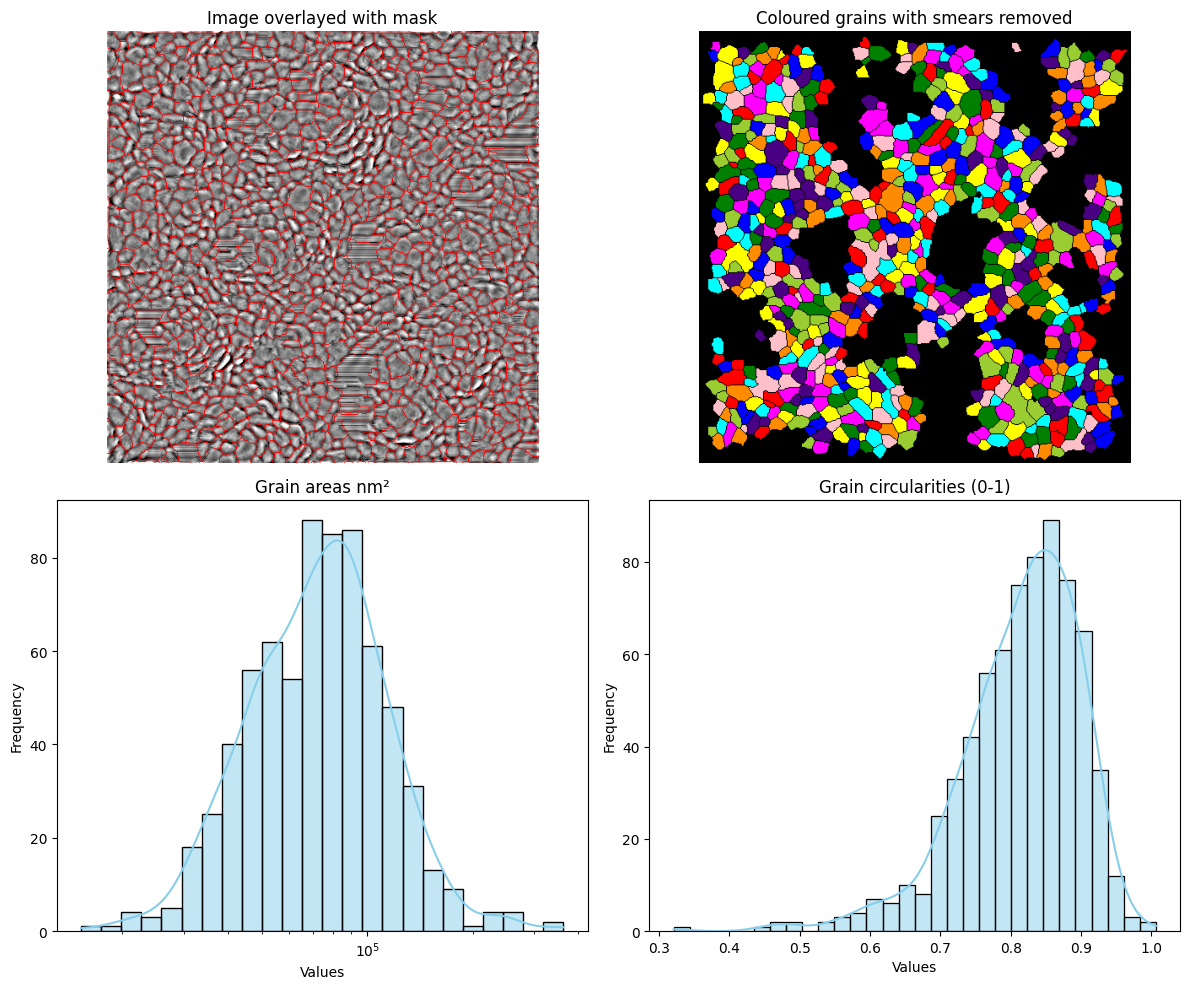

In [9]:
import seaborn as sns

# Identify individual grains from mask and generate statistics on them
find_grains(perovstats_object.config, image_object)


# Display data and statistics on the processed image and grains
fig, ax = plt.subplots(2, 2, figsize=(12, 10))

ax[0,0].imshow(mask_overlay)
ax[0,0].set_title("Image overlayed with mask")
ax[0,0].axis("off")

ax[0,1].imshow(image_object.mask_rgb)
ax[0,1].set_title("Coloured grains with smears removed")
ax[0,1].axis("off")

sns.histplot(image_object.mask_areas, bins='auto', kde=True, log_scale=True, color='skyblue', edgecolor='black', ax=ax[1,0])
ax[1,0].set_xlabel('Values')
ax[1,0].set_ylabel('Frequency')
ax[1,0].set_title('Grain areas nm²')

sns.histplot(image_object.circularity_data, bins='auto', kde=True, color='skyblue', edgecolor='black', ax=ax[1,1])
ax[1,1].set_xlabel('Values')
ax[1,1].set_ylabel('Frequency')
ax[1,1].set_title('Grain circularities (0-1)')

plt.tight_layout()
plt.show()

Data (including the config options used in the run) are now exported to the output directory chosen at the top of this notebook:

In [10]:
logger.info(f"[{image_object.filename}] : *** Exporting data ***")
# Save image and grain data to their own .csv file
image_df = pd.DataFrame([image_object.to_dict()])
grains_list = []
for grain in image_object.grains.values():
    grains_list.append(grain.to_dict())
grain_df = pd.DataFrame(grains_list)

output_filename = f"{output_dir}/{image_object.filename}/image_statistics.csv"
save_to_csv(image_df, output_filename)
output_filename = f"{output_dir}/{image_object.filename}/grain_statistics.csv"
save_to_csv(grain_df, output_filename)
# Save the config settings in a .yaml
output_filename = Path(output_dir) / Path(image_object.filename) / "config.yaml"
save_config(perovstats_object.config, output_filename)

logger.info(
    f"[{image_object.filename}] : Exported data and config to {Path(output_dir) / Path(image_object.filename)}",
)

21:59:34 | INFO    | 2787836878.py   | [4_c60_perovonsil_ref_10um.PFQNM.spm] : *** Exporting data ***
21:59:34 | INFO    | 2787836878.py   | [4_c60_perovonsil_ref_10um.PFQNM.spm] : Exported data and config to output\4_c60_perovonsil_ref_10um.PFQNM.spm
